In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [52]:
df = pd.read_csv("../output/combined_projections.csv")

In [53]:
output_dir = Path("../output/bar_figures")
output_dir.mkdir(parents=True, exist_ok=True)

In [54]:
df_long = df.melt(
    id_vars=["model_name", "model_variation", "dimension"], 
    value_vars=["female_names", "male_names"], 
    var_name="gender", 
    value_name="score"
)
df_long["gender"] = df_long["gender"].str.replace("_names", "").str.capitalize()

def get_group(val):
    if "default" in val:
        return "Default"
    for v in ["conservative", "democratic", "liberal"]:
        if v in val:
            return v.capitalize()
    return "Other"

df_long["variation_group"] = df_long["model_variation"].apply(get_group)

In [56]:
from scipy.stats import wilcoxon, ttest_1samp

default_map = df_long[df_long["variation_group"] == "Default"].set_index(
    ["model_name", "dimension", "gender"]
)["score"]

def perform_ttest(group):
    model, var_group, dim, gender = group.name
    baseline = default_map.loc[(model, dim, gender)]
    
    # T-Test
    t_stat, p_val = ttest_1samp(group["score"], popmean=baseline)
    return p_val

variations_only = df_long[df_long["variation_group"] != "Default"]

p_values_series = variations_only.groupby(
    ["model_name", "variation_group", "dimension", "gender"]
).apply(perform_ttest, include_groups=False)

significance_df = p_values_series.reset_index(name="p_value")

In [75]:
alpha = 0.01
target_aspects = ["Conservative", "Democratic", "Liberal"]

male_palette = {
    "Default": sns.color_palette()[7],
    "Conservative": sns.color_palette()[3], 
    "Liberal": sns.color_palette()[2],      
    "Democratic": sns.color_palette()[0]    
}

low_labels = {
    "Sociability": "Low sociability",
    "Morality": "Low morality",
    "Ability": "Low ability",
    "Agency": "Low agency",
    "Status": "Low status",
    "Politics": "Progressive",
    "Religion": "Non-religious"
}

high_labels = {
    "Sociability": "High sociability",
    "Morality": "High morality",
    "Ability": "High ability",
    "Agency": "High agency",
    "Status": "High status",
    "Politics": "Traditional",
    "Religion": "Religious"
}


for model in df_long["model_name"].unique():
    print(f"Plotting: {model}")
    
    subset_df = df_long[
        (df_long["model_name"] == model)
    ].copy()
    
    present_groups = subset_df[subset_df["gender"] == "Male"]["variation_group"].unique()
    hue_order = [g for g in male_palette.keys() if g in present_groups]

    sns.set_theme(style="whitegrid")
    fig, ax = plt.subplots(figsize=(4, 5))

    ax.set_title(f"{model}")

    sns.barplot(
        data=subset_df[subset_df["gender"] == "Male"],
        x="score", y="dimension", hue="variation_group",
        palette=male_palette,
        hue_order=hue_order,
        ax=ax
    )
    
    if ax.get_legend():
        ax.get_legend().remove()
    
    ax.set_xlabel("Male Bias")
    ax.set_ylabel("")
    
    fig.canvas.draw()

    dims = [t.get_text() for t in ax.get_yticklabels()]
    x_limit_range = abs(ax.get_xlim()[1] - ax.get_xlim()[0])
    offset_buffer = 0.01 * x_limit_range
    
    line_idx = 0

    for group_idx, container in enumerate(ax.containers):
        
        if group_idx >= len(hue_order):
            continue
            
        group = hue_order[group_idx]
        
        for dim_idx, patch in enumerate(container):   
            
            error_line = None
            if line_idx < len(ax.lines):
                error_line = ax.lines[line_idx]
            
            line_idx += 1

            if group == "Default":
                continue
                
            if dim_idx >= len(dims): 
                continue 
            dim = dims[dim_idx]

            p_row = significance_df[
                (significance_df["model_name"] == model) &
                (significance_df["dimension"] == dim) &
                (significance_df["gender"] == "Male") &
                (significance_df["variation_group"] == group)
            ]
            
            if p_row.empty:
                continue
            
            p = p_row["p_value"].iloc[0]
            
            star = None
            if p < alpha:
                star = "*"
            
            if star is None:
                continue
                
            width = patch.get_width()
            y_pos = patch.get_y() + patch.get_height() / 2 + 0.055
            
            ref_x = width
            
            if error_line is not None:
                x_data = error_line.get_xdata()
                if len(x_data) > 0:
                    if width < 0:
                        ref_x = x_data.min()
                    else:
                        ref_x = x_data.max()
            
            if width < 0:
                x_pos = ref_x - offset_buffer
                align_h = "right"
            else:
                x_pos = ref_x + offset_buffer
                align_h = "left"
            
            ax.text(
                x_pos,
                y_pos,
                star,
                va="center",
                ha=align_h,
                fontsize=10,
                fontweight="bold",
                color="black"
            )

    current_yticks = ax.get_yticks()
    new_labels_low = [low_labels.get(d, d) for d in dims]
    new_labels_high = [high_labels.get(d, d) for d in dims]

    ax.set_yticks(current_yticks)
    ax.set_yticklabels(new_labels_low)
    
    ax.tick_params(labelright=True, right=True)
    ax2 = ax.twinx()
    ax2.set_ylim(ax.get_ylim()) 
    ax2.set_yticks(current_yticks)      
    ax2.set_yticklabels(new_labels_high)
    
    ax2.grid(False)

    plt.savefig(f"{output_dir}/{model}.pdf", bbox_inches='tight')
    plt.savefig(f"{output_dir}/{model}.png", bbox_inches='tight', dpi=600)
    plt.close()

Plotting: Qwen3-8B
Plotting: Meta-Llama-3-8B
Plotting: Apertus-8B-Instruct-2509


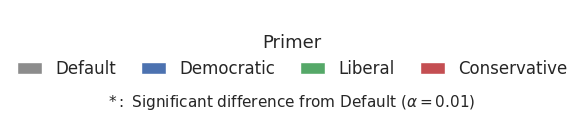

In [90]:
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=male_palette["Default"], label="Default"),
    Patch(facecolor=male_palette["Democratic"], label="Democratic"),
    Patch(facecolor=male_palette["Liberal"], label="Liberal"),
    Patch(facecolor=male_palette["Conservative"], label="Conservative"),
]

fig_leg = plt.figure(figsize=(6, 1.2))  

plt.legend(
    handles=legend_elements,
    title="Primer",
    loc="center",
    ncol=4,          
    frameon=False,
    fontsize=12,
    title_fontsize=13,
    handlelength=1.5,
    columnspacing=1.5
)

plt.text(
    0.5,
    -0.1,
    r"$*: \text{ Significant difference from Default } (\alpha=0.01)$",
    ha="center",
    va="bottom",
    fontsize=11,
)

plt.axis('off')

plt.savefig(f"{output_dir}/legend.pdf", bbox_inches='tight')
plt.savefig(f"{output_dir}/legend.png", bbox_inches='tight', dpi=600)